In [61]:
import pandas as pd
import numpy as np
from pandas import DataFrame
import warnings
warnings.filterwarnings("ignore")

In [186]:
df1 = pd.read_csv('D:\\Academic\\Research\\ML_Python_Code_by_MRK\\MICS Data\Different domains prediction\\Children learning capacity\\chlebeled.csv')
df1.head(3)

,Unnamed: 0,Removed_privileges,Shook_child,Called_dumb_lazy,Beat_hard,Learning_skill,Child's_weight,Sex,Weight_age_P,Wealth_index,Mother's_education
0,0,2,2,1,2,0,16.3,1,15.4,5,3
1,2,2,2,2,2,0,9.8,2,0.1,4,1
2,3,2,1,2,2,0,14.7,1,19.0,5,3


In [187]:
"""
df1=df1[['UCD2A', 'UCD2C', 'UCD2G', 'UCD2H', 'UCD2I', 'UCD2J','UCD2K','UCF17', 'AN4', 'AN8', 'HH6', 'HL4', 'windex5', 'melevel']]
for col in df1.columns:
    print(col)
    print(df1[col].unique())
"""
df1=df1.drop(['Unnamed: 0'],axis=1)
df1.head(5)

,Removed_privileges,Shook_child,Called_dumb_lazy,Beat_hard,Learning_skill,Child's_weight,Sex,Weight_age_P,Wealth_index,Mother's_education
0,2,2,1,2,0,16.3,1,15.4,5,3
1,2,2,2,2,0,9.8,2,0.1,4,1
2,2,1,2,2,0,14.7,1,19.0,5,3
3,1,2,2,2,0,13.0,2,1.6,5,3
4,2,1,2,2,0,11.7,2,32.8,5,3


### Category-wise

In [188]:
factors=[]
lbw_n=[]
nbw_n=[]
OR=[]
SE=[]
CI_low=[]
CI_high=[]
pvalue=[]

In [190]:
categorical_features = df1=df1.drop(['Child\'s_weight','Weight_age_P'],axis=1)
#categorical_features=categorical_features.drop(['lbw'],axis=1)
categorical_features.columns

Index(['Removed_privileges', 'Shook_child', 'Called_dumb_lazy', 'Beat_hard',
       'Learning_skill', 'Sex', 'Wealth_index', 'Mother's_education'],
      dtype='object')

In [191]:
for col in df1.columns:
    print(col)
    print(df1[col].unique())


Removed_privileges
[2 1]
Shook_child
[2 1]
Called_dumb_lazy
[1 2]
Beat_hard
[2 1]
Learning_skill
[0 1]
Sex
[1 2]
Wealth_index
[5 4 2 1 3]
Mother's_education
[3 1 2 0]


In [192]:
from scipy.stats import chi2_contingency

for feature in categorical_features.columns:
    factors.append(feature)
    categories=df1[feature].unique()
    categories.sort()
    factors=factors+categories.tolist()
    
    pvalue.append(' ')
    nbw_n.append(' ')
    lbw_n.append(' ')
    OR.append(' ')
    SE.append(' ')
    CI_low.append(' ')
    CI_high.append(' ')
    
    print("____________________________**************____________________________")
    l=len(categories)
    r=categories[0]
    for cat in categories:
        n1=df1[feature][(df1[feature] ==cat)&(df1['Learning_skill'] ==0)].count()
        n2=df1[feature][(df1[feature] ==cat)&(df1['Learning_skill'] ==1)].count()
        print(n1)
        #p-value
        data_cat=df1[feature][(df1[feature] ==cat)|(df1[feature] ==r)]
        size=data_cat.count()
        if(size!=0):
            # Create a contingency table (cross-tabulation)
            contingency_table = pd.crosstab(data_cat, df1['Learning_skill'], margins=True)

            # Perform chi-square test
            chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

            # Calculate odds ratio
            odds_ratio = (contingency_table.iloc[0, 0] / contingency_table.iloc[1, 0]) / (contingency_table.iloc[0, 1] / contingency_table.iloc[1, 1])

            # Calculate standard error of the natural log of the odds ratio
            se = np.sqrt(1 / contingency_table.iloc[0, 0] + 1 / contingency_table.iloc[1, 0] + 1 / contingency_table.iloc[0, 1] + 1 / contingency_table.iloc[1, 1])

            # Calculate 95% confidence interval for the odds ratio
            ci_lower = np.exp(np.log(odds_ratio) - 1.96 * se)
            ci_upper = np.exp(np.log(odds_ratio) + 1.96 * se)

            nbw_n.append(n1)
            lbw_n.append(n2)
            OR.append(odds_ratio)
            pvalue.append(p_value)
            SE.append(se)
            CI_low.append(ci_lower)
            CI_high.append(ci_upper)

            print("____________________________")
            print(feature,":")
            print("-------------")
            print(contingency_table)
            print('_____________')
            print("oddsRatio=",odds_ratio)
            print("se=",se)
        else:
            pvalue.append(' ')
            nbw_n.append(' ')
            lbw_n.append(' ')
            OR.append(' ')
            SE.append(' ')
            CI_low.append(' ')
            CI_high.append(' ')
            odd_ratio.append(' ')



____________________________**************____________________________
5941
____________________________
Removed_privileges :
-------------
Learning_skill         0    1   All
Removed_privileges                 
1                   5941  480  6421
All                 5941  480  6421
_____________
oddsRatio= 1.0
se= 0.06710670852716379
6516
____________________________
Removed_privileges :
-------------
Learning_skill          0    1    All
Removed_privileges                   
1                    5941  480   6421
2                    6516  337   6853
All                 12457  817  13274
_____________
oddsRatio= 0.6401284658277061
se= 0.07329722096118342
____________________________**************____________________________
5364
____________________________
Shook_child :
-------------
Learning_skill     0    1   All
Shook_child                    
1               5364  436  5800
All             5364  436  5800
_____________
oddsRatio= 1.0
se= 0.0704273529309232
7093
__________________

In [193]:
print(len(factors))
print(len(nbw_n))
print(len(lbw_n))
print(len(pvalue))
print(len(OR))
print(len(SE))
print(len(CI_low))
print(len(CI_high))

29
29
29
29
29
29
29
29


In [194]:
df1.shape

(13274, 8)

In [195]:
# Sample DataFrame
data = {'Factors':factors,
        'No Difficulties': nbw_n,
        'Have Difficulties': lbw_n,
        'pvalue': pvalue,
        'SE': SE,
        'OR': OR,
        '95% CI (LOW)': CI_low,
        '95% CI (High)': CI_high,
        }  # Initialize Grade column with None

df_stat = pd.DataFrame(data)

In [197]:
df_stat.head(60)

,Factors,No Difficulties,Have Difficulties,pvalue,SE,OR,95% CI (LOW),95% CI (High)
0,Removed_privileges,,,,,,,
1,1,5941,480,1.0,0.067107,1.0,0.876754,1.140571
2,2,6516,337,0.0,0.073297,0.640128,0.554466,0.739025
3,Shook_child,,,,,,,
4,1,5364,436,1.0,0.070427,1.0,0.871066,1.148019
5,2,7093,381,0.000001,0.072427,0.660841,0.573385,0.761638
6,Called_dumb_lazy,,,,,,,
7,1,2955,244,1.0,0.094199,1.0,0.831411,1.202774
8,2,9502,573,0.003268,0.079292,0.73031,0.625191,0.853104
9,Beat_hard,,,,,,,


In [198]:
df_stat.to_excel('D:\\Academic\\Research\\ML_Python_Code_by_MRK\\MICS Data\Different domains prediction\\Children learning capacity\\table2.xlsx')

PermissionError: [Errno 13] Permission denied: 'D:\\Academic\\Research\\ML_Python_Code_by_MRK\\MICS Data\\Different domains prediction\\Children learning capacity\\table2.xlsx'

# Logistic

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
df1 = pd.read_csv('D:\\Academic\\Research\\ML_Python_Code_by_MRK\\MICS Data\Different domains prediction\\Children learning capacity\\chlebeled.csv')


In [3]:
df1=df1.drop(['Unnamed: 0'],axis=1)
df1.head(10)

,Removed_privileges,Shook_child,Called_dumb_lazy,Beat_hard,Learning_skill,Child's_weight,Sex,Weight_age_P,Wealth_index,Mother's_education
0,2,2,1,2,0,16.3,1,15.4,5,3
1,2,2,2,2,0,9.8,2,0.1,4,1
2,2,1,2,2,0,14.7,1,19.0,5,3
3,1,2,2,2,0,13.0,2,1.6,5,3
4,2,1,2,2,0,11.7,2,32.8,5,3
5,1,1,2,1,0,12.3,1,4.4,2,2
6,1,1,2,1,1,15.1,2,54.6,4,2
7,1,2,2,2,0,15.9,2,28.1,5,1
8,1,1,1,2,0,14.8,1,28.3,2,1
9,1,1,2,1,1,11.6,1,0.8,1,1


In [4]:
Min=min(df1['Weight_age_P'])
print(Min)

0.0


In [5]:
Max=max(df1['Weight_age_P'])
print(Max)

89.3


In [6]:
df1.columns

Index(['Removed_privileges', 'Shook_child', 'Called_dumb_lazy', 'Beat_hard',
       'Learning_skill', 'Child's_weight', 'Sex', 'Weight_age_P',
       'Wealth_index', 'Mother's_education'],
      dtype='object')

In [7]:
numeric_features = df1[['Child\'s_weight','Weight_age_P','Learning_skill']]
numeric_features.describe()

,Child's_weight,Weight_age_P,Learning_skill
count,13274.000000,13274.000000,13274.000000
mean,12.791540,13.597544,0.061549
std,2.150944,18.007805,0.240343
min,1.100000,0.000000,0.000000
25%,11.300000,1.500000,0.000000
50%,12.700000,5.800000,0.000000
75%,14.200000,18.200000,0.000000
max,21.200000,89.300000,1.000000


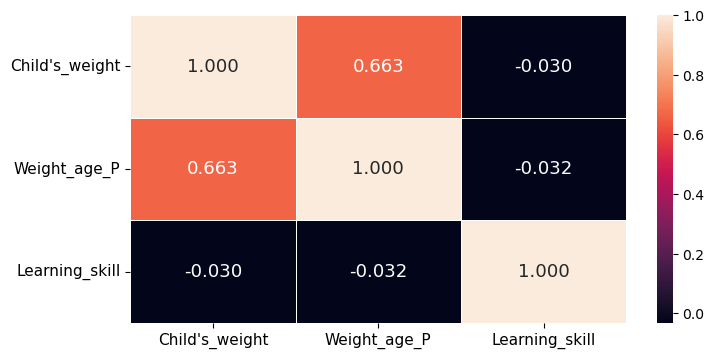

In [23]:
#correlation map
import seaborn as sns
from matplotlib import pyplot as plt
# Create a figure and axis
f, ax = plt.subplots(figsize=(8, 4))

# Create the heatmap
sns.heatmap(numeric_features.corr(), annot=True, linewidths=.5, fmt='.3f', ax=ax, annot_kws={'size': 13})

ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)
# Show the plot
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import MinMaxScaler

num_features1 = df1[['Child_s_weight','Weight_for_age_percentile']]
df_temp = df1.drop(num_features1.columns, axis=1)

scale = StandardScaler()
#scale = Normalizer()
#scale = MinMaxScaler()
scaledX = scale.fit_transform(num_features1)
scale_df = DataFrame(scaledX, columns = num_features1.columns)

df_Scale = pd.concat([scale_df.reset_index(drop=True),df_temp.reset_index(drop=True)], axis=1)
df_Scale.shape

In [100]:
#from sklearn.preprocessing import LabelEncoder
#number=LabelEncoder()

#logistic lbw  i.WAGE i.MA1 i.MA3 i.CM8 i.CM11 i.MN2 i.MN5 i.MN6B i.MN6C i.MN7 i.MN8 i.CP2 i.LS1 i.HH6 i.BH3_last i.windex5 i.welevel, baselevels
#model = smf.logit("UCF17 ~ (UCD2A)+C(UCD2C)+C(UCD2K)+AN4+AN8+HAP+BMI+C(HL4)+C(windex5)+C(melevel)", data=df1).fit()
model = smf.logit("UCF17 ~C(Took_away_privileges,Treatment(2))+C(Shook_child,Treatment(2))+C(Called_child_dumb_lazy,Treatment(2))+C(Beat_child_up_as_hard_as_one_could,Treatment(2))+Child_s_weight+Weight_for_age_percentile+C(Sex,Treatment(2))+C(Wealth_index,Treatment(5))+C(Mother_s_education,Treatment(3))", data=df1).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.221283
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  UCF17   No. Observations:                13385
Model:                          Logit   Df Residuals:                    13370
Method:                           MLE   Df Model:                           14
Date:                Fri, 16 Aug 2024   Pseudo R-squ.:                 0.03883
Time:                        16:38:48   Log-Likelihood:                -2961.9
converged:                       True   LL-Null:                       -3081.5
Covariance Type:            nonrobust   LLR p-value:                 4.595e-43
                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept       

In [101]:
model_odds = pd.DataFrame(np.exp(model.params), columns= ['OR'])
model_odds['p-value']= model.pvalues
model_odds['std_err']= model.bse
model_odds[['2.5%', '97.5%']] = np.exp(model.conf_int())

model_odds

,OR,p-value,std_err,2.5%,97.5%
Intercept,0.036150,6.503107e-27,0.309091,0.019725,0.066253
"C(Took_away_privileges, Treatment(2))[T.1]",1.489665,1.423034e-07,0.075738,1.284164,1.728051
"C(Shook_child, Treatment(2))[T.1]",1.259845,2.340604e-03,0.075903,1.085697,1.461928
"C(Called_child_dumb_lazy, Treatment(2))[T.1]",1.077304,3.763537e-01,0.084173,0.913462,1.270534
"C(Beat_child_up_as_hard_as_one_could, Treatment(2))[T.1]",2.264550,4.462883e-11,0.124074,1.775703,2.887976
"C(Sex, Treatment(2))[T.1]",1.214587,9.212837e-03,0.074654,1.049259,1.405965
"C(Wealth_index, Treatment(5))[T.1]",2.611713,9.199228e-11,0.148159,1.953494,3.491715
"C(Wealth_index, Treatment(5))[T.2]",1.841174,6.573522e-05,0.152937,1.364316,2.484704
"C(Wealth_index, Treatment(5))[T.3]",1.400983,3.318428e-02,0.158309,1.027259,1.910670
"C(Wealth_index, Treatment(5))[T.4]",1.274796,1.279245e-01,0.159482,0.932586,1.742579


In [102]:
model_odds.to_excel('D:\\Academic\\Research\\ML_Python_Code_by_MRK\\MICS Data\Different domains prediction\\Children learning capacity\\table1_stat.xlsx')

https://economics.stackexchange.com/questions/35800/python-vs-r-vs-stata-the-old-battle-revisited

https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.RegressionResults.html

https://www.pythonfordatascience.org/logistic-regression-python/

https://github.com/JiguangPeng/odds_ratio

https://www.scalestatistics.com/unadjusted-odds-ratio.html

https://www.blog.trainindata.com/overcoming-class-imbalance-with-smote/#:~:text=The%20k%20parameter%20in%20SMOTE,to%20optimize%20using%20cross%2Dvalidation.

https://practicaldatascience.co.uk/machine-learning/how-to-use-smote-for-imbalanced-classification

https://scipy.github.io/devdocs/reference/stats.contingency.html

https://scipy.github.io/devdocs/reference/stats.contingency.html

https://datasciencestunt.com/understanding-confidence-interval-null-hypothesis-and-p-value-in-logistic-regression/

Calculation of p-value by chi-square test Background knowledge is explained with Manual Calculation.
The chi-square test is a statistical test used to determine if there is a significant association between two categorical variables. It compares the observed frequencies in a contingency table to the expected frequencies under the assumption of independence between the variables. Here's a step-by-step guide on how to perform a chi-square test:

Formulate Hypotheses:

Null Hypothesis (H0): There is no significant association between the two variables.
Alternative Hypothesis (Ha): There is a significant association between the two variables.
Collect and Organize Data:

Create a contingency table that displays the observed frequencies for each combination of categories in the two categorical variables.
Calculate Expected Frequencies:

Calculate the expected frequencies for each cell in the contingency table assuming independence between the variables. The formula is:
Expected Frequency = (Row Total * Column Total) / Grand Total
Calculate Chi-Square Statistic:

For each cell, calculate the contribution to the chi-square statistic using the formula:
Contribution = (Observed Frequency - Expected Frequency)^2 / Expected Frequency
Sum up the contributions from all cells to get the chi-square statistic:
Chi-Square = Σ Contribution for all cells
Degrees of Freedom:

Calculate the degrees of freedom using the formula: Degrees of Freedom = (Number of Rows - 1) * (Number of Columns - 1)
Critical Value or P-value:

Look up the critical value from the chi-square distribution table for your chosen significance level and degrees of freedom.
Alternatively, use statistical software to find the p-value associated with your calculated chi-square statistic.
Compare and Interpret:

If using critical values, compare the calculated chi-square statistic to the critical value. If the calculated chi-square is greater than the critical value, reject the null hypothesis.
If using p-values, compare the p-value to the chosen significance level (e.g., 0.05). If p-value less than significance level, reject the null hypothesis.
Interpret Results:

If the null hypothesis is rejected, you can conclude that there is a significant association between the two categorical variables.
If the null hypothesis is not rejected, you cannot conclude a significant association between the variables.
Report Results:

In your research report, provide the calculated chi-square statistic, degrees of freedom, p-value, and your conclusion regarding the null hypothesis.
It's important to note that the chi-square test assumes certain conditions, such as the expected frequency in each cell being at least 5. If this assumption is violated, you might need to consider alternatives like Fisher's exact test or use specialized software that handles low expected frequencies.